# py-TSCAN — Tutorial on `lpsdata`

Walkthrough of every public algorithmic function in `pytscan`, covered in [`RECONSTRUCTION_REPORT.md §2.2`](../RECONSTRUCTION_REPORT.md): `preprocess` → `exprmclust` → `TSCANorder` → `difftest` → `orderscore`, plus the AnnData-native class API.

Demo data: TSCAN's bundled **`lpsdata`** — 131 mouse BMDC cells (unstimulated vs 6h LPS-stimulated) × 16776 genes (Shalek et al., *Nature* 2014, GSE48968).

## 1. What this package does

`pytscan` is a pure-Python port of [`TSCAN`](https://github.com/zji90/TSCAN) (Ji & Ji, *Nucleic Acids Research* 44(13), 2016) — **T**rajectory inference via **S**ingle-cell **C**lustering using **A**utomated **N**etwork analysis. It orders cells along a continuous pseudotime by:

1. Filtering low-expression / low-CV genes,
2. PCA-reducing with automatic dimension selection (piecewise-linear elbow),
3. Model-based clustering (Mclust VVV) on the PC scores,
4. Building a minimum spanning tree (MST) on the cluster centres,
5. Finding the longest leaf-to-leaf path in the MST,
6. Projecting cells onto the cluster-edge vectors to obtain the final ordering.

**Input**: a `genes × cells` matrix of raw counts (R convention) or an `AnnData` (`cells × genes`).
**Output**: a per-cell pseudotime + state, optionally trajectory-DE genes.

> Citation: Ji, Z. & Ji, H. *TSCAN: pseudo-time reconstruction and evaluation in single-cell RNA-seq analysis.* Nucleic Acids Research 44(13), e117 (2016).

## 2. Install + import

In [1]:
# pip install pytscan
import sys
sys.path.insert(0, '/scratch/users/steorra/analysis/omicverse_traj_dev/py-TSCAN')
sys.path.insert(0, '/scratch/users/steorra/analysis/omicverse_dev/py-mclustR')

import pytscan
from pytscan import preprocess, exprmclust, TSCANorder, orderscore  # R-mirror functional API
from pytscan import TSCAN  # AnnData-native class API
print(f'pytscan version: {pytscan.__version__}')

pytscan version: 0.1.0


## 3. Load demo data

In [2]:
import pyreadr
from pathlib import Path

PORT_DIR = Path('.').resolve().parent if Path('.').resolve().name == 'examples' else Path('.').resolve()
lpsdata = next(iter(pyreadr.read_r(PORT_DIR / 'data' / 'fixture_lpsdata.rds').values()))
print(f'shape (genes × cells): {lpsdata.shape}')
print(f'gene names sample: {list(lpsdata.index[:3])}')
print(f'cell names sample: {list(lpsdata.columns[:3])}')
print(f'\nThe 131 cells split into two biological groups encoded in cell names:')
import re
groups = {n.split('_')[0]+'_'+n.split('_')[1] if 'LPS' in n else 'Unstimulated' for n in lpsdata.columns}
import pandas as pd
print(pd.Series([n.rsplit('_', 1)[0] for n in lpsdata.columns]).value_counts().to_string())

shape (genes × cells): (16776, 131)
gene names sample: ['XKR4', 'B3GAT2', 'NPL']
cell names sample: ['Unstimulated_S15', 'Unstimulated_S16', 'Unstimulated_S17']

The 131 cells split into two biological groups encoded in cell names:
LPS_6h          74
Unstimulated    57


## 4. Public functions

### 4.1 `preprocess(data, ...)` — log + filter genes

R equivalent: `preprocess(data, takelog=TRUE, logbase=2, pseudocount=1, minexpr_value=1, minexpr_percent=0.5, cvcutoff=1)`

Takes log₂(counts + 1), then drops genes with fewer than 50% of cells above the expression floor OR with coefficient-of-variation below 1. Returns a smaller `genes × cells` DataFrame.

In [3]:
procdata = preprocess(lpsdata)
print(f'Before: {lpsdata.shape}  → After: {procdata.shape}')
print(f'Kept {procdata.shape[0]:>5d} of {lpsdata.shape[0]:>5d} genes ({100*procdata.shape[0]/lpsdata.shape[0]:.1f}%)')
print(f'\nSample of filtered expression matrix:')
print(procdata.iloc[:3, :3].round(2))

Before: (16776, 131)  → After: (534, 131)
Kept   534 of 16776 genes (3.2%)

Sample of filtered expression matrix:
        Unstimulated_S15  Unstimulated_S16  Unstimulated_S17
STX6                8.19              5.82              3.31
MRPL28              9.22              5.81              9.19
CUTA                6.80              8.29              7.66


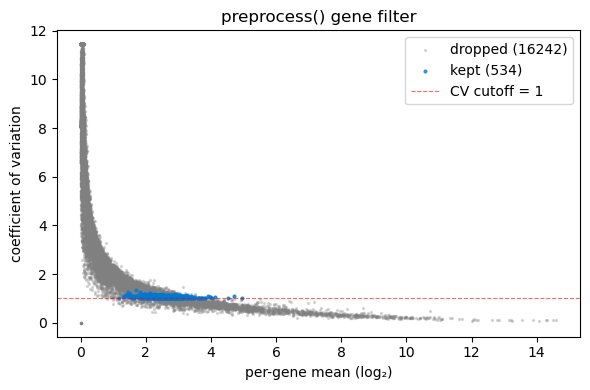

In [4]:
# Visualise the filtering: per-gene mean vs CV, before and after.
import matplotlib.pyplot as plt
import numpy as np
log_data = np.log2(lpsdata.values + 1)
mu_all = log_data.mean(axis=1); cv_all = log_data.std(axis=1, ddof=1)/np.maximum(mu_all, 1e-9)
mu_keep = procdata.mean(axis=1).values; cv_keep = procdata.std(axis=1, ddof=1).values/np.maximum(mu_keep, 1e-9)

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(mu_all, cv_all, s=2, alpha=0.25, color='grey', label=f'dropped ({lpsdata.shape[0]-procdata.shape[0]})')
ax.scatter(mu_keep, cv_keep, s=4, alpha=0.7, color='#0078d4', label=f'kept ({procdata.shape[0]})')
ax.axhline(1.0, color='red', ls='--', lw=0.8, alpha=0.6, label='CV cutoff = 1')
ax.set_xlabel('per-gene mean (log₂)'); ax.set_ylabel('coefficient of variation')
ax.set_title('preprocess() gene filter')
ax.legend(loc='upper right'); plt.tight_layout(); plt.show()

### 4.2 `exprmclust(data, ...)` — PCA + adaptive PC dim + Mclust + MST

R equivalent: `exprmclust(data, clustermethod='mclust', clusternum=2:9, modelNames='VVV', reduce=TRUE)`

Returns an `ExprMclustResult` dataclass with five fields:
- `pcareduceres`: cells × pcadim PCA scores
- `clucenter`: G × pcadim cluster centroids
- `clusterid`: 1-D vector of cluster IDs (1..G per cell)
- `MSTtree`: a `networkx.Graph` (G nodes, G-1 edges)
- `pcadim`: the auto-selected number of PCs (piecewise-linear elbow on the first 20 singular values)

In [5]:
mc = exprmclust(procdata)
print(f'pcadim (auto-selected):  {mc.pcadim}')
print(f'pcareduceres shape:       {mc.pcareduceres.shape}')
print(f'cluster_id sizes:         {dict(zip(*np.unique(mc.clusterid, return_counts=True)))}')
print(f'clucenter shape:          {mc.clucenter.shape}')
print(f'MST edges:                {list(mc.MSTtree.edges(data=True))}')

pcadim (auto-selected):  5
pcareduceres shape:       (131, 5)
cluster_id sizes:         {1: 44, 2: 57, 3: 30}
clucenter shape:          (3, 5)
MST edges:                [(1, 2, {'weight': 12.139926269939203}), (2, 3, {'weight': 9.521283093558162})]


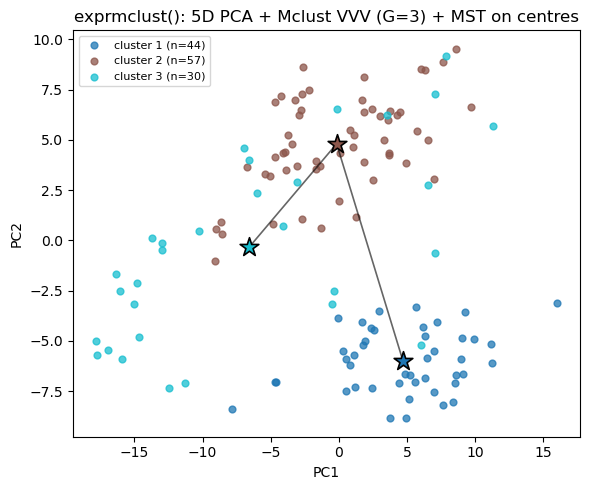

In [6]:
# Visualise the cluster structure: PC1 vs PC2 with MST overlay on centres.
import networkx as nx
fig, ax = plt.subplots(figsize=(6, 5))
colors = plt.cm.tab10(np.linspace(0, 1, int(mc.clusterid.max())))
for k in range(1, int(mc.clusterid.max())+1):
    pts = mc.pcareduceres[mc.clusterid == k]
    ax.scatter(pts[:, 0], pts[:, 1], s=24, color=colors[k-1], label=f'cluster {k} (n={pts.shape[0]})', alpha=0.75)
# centres
for k in range(mc.clucenter.shape[0]):
    ax.scatter(mc.clucenter[k, 0], mc.clucenter[k, 1], s=200, marker='*',
               edgecolors='black', color=colors[k], linewidths=1.2, zorder=5)
# MST edges
for u, v in mc.MSTtree.edges():
    ax.plot([mc.clucenter[u-1, 0], mc.clucenter[v-1, 0]],
            [mc.clucenter[u-1, 1], mc.clucenter[v-1, 1]],
            'k-', lw=1.2, alpha=0.6, zorder=4)
ax.set_xlabel(f'PC1'); ax.set_ylabel('PC2')
ax.set_title(f'exprmclust(): {mc.pcareduceres.shape[1]}D PCA + Mclust VVV (G={int(mc.clusterid.max())}) + MST on centres')
ax.legend(fontsize=8, loc='best'); plt.tight_layout(); plt.show()

### 4.3 `TSCANorder(mclustobj, ...)` — pseudotime ordering

R equivalent: `TSCANorder(mclustobj, startcluster=NULL, MSTorder=NULL, orderonly=FALSE, flip=FALSE)`

Finds the longest leaf-to-leaf path in the MST, then for each consecutive cluster pair projects cells onto the difference vector `centre_{i+1} − centre_i` and concatenates the sorted projections.

Returns a `TSCANorderResult` with:
- `ordered_names`: cell names in pseudotime order
- `df`: DataFrame `(sample_name, State, Pseudotime)` if `orderonly=False`
- `MSTorder`: the backbone path (list of cluster IDs)

In [7]:
ord_res = TSCANorder(mc, orderonly=False)
print(f'Backbone path (MSTorder): {ord_res.MSTorder}')
print(f'Ordered {len(ord_res.ordered_names)} cells')
print(f'\nFirst 5 cells in pseudotime order:')
print(ord_res.df.head().to_string(index=False))
print(f'\nLast 5:')
print(ord_res.df.tail().to_string(index=False))

Backbone path (MSTorder): [1, 2, 3]
Ordered 131 cells

First 5 cells in pseudotime order:
     sample_name  State  Pseudotime
Unstimulated_S60      1           1
Unstimulated_S38      1           2
Unstimulated_S28      1           3
Unstimulated_S93      1           4
Unstimulated_S66      1           5

Last 5:
     sample_name  State  Pseudotime
Unstimulated_S37      3         127
      LPS_6h_S78      3         128
      LPS_6h_S67      3         129
      LPS_6h_S19      3         130
 Unstimulated_S7      3         131


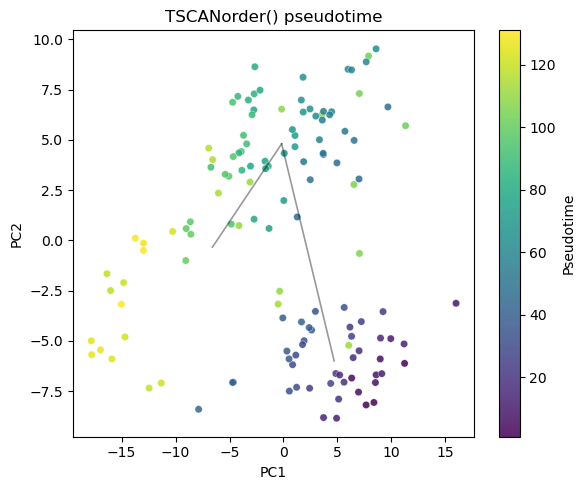

In [8]:
# Pseudotime overlaid on the PCA scatter.
pt_by_cell = ord_res.df.set_index('sample_name')['Pseudotime'].reindex(procdata.columns).values

fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(mc.pcareduceres[:, 0], mc.pcareduceres[:, 1], c=pt_by_cell,
                cmap='viridis', s=28, alpha=0.85, edgecolors='white', linewidths=0.3)
for u, v in mc.MSTtree.edges():
    ax.plot([mc.clucenter[u-1, 0], mc.clucenter[v-1, 0]],
            [mc.clucenter[u-1, 1], mc.clucenter[v-1, 1]],
            'k-', lw=1.2, alpha=0.4, zorder=4)
plt.colorbar(sc, ax=ax, label='Pseudotime')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('TSCANorder() pseudotime')
plt.tight_layout(); plt.show()

### 4.4 `difftest(data, order, df=3)` — trajectory-DE

R equivalent: `difftest(data, order, df=3)` — fits a GAM `gene ~ s(pseudotime, k=df)` and reports a likelihood-ratio χ² p-value per gene, plus BH-FDR.

Requires `pygam` (optional install: `pip install pytscan[de]`).

In [9]:
try:
    from pytscan import difftest
    # Run on a small subset of 50 genes to keep this notebook fast
    de = difftest(procdata.iloc[:50], ord_res.ordered_names, df=3)
    print(f'Tested {de.shape[0]} genes. Top 10 by FDR:')
    print(de.head(10).to_string())
except ImportError as e:
    print('difftest unavailable —', e)
    print('Install with: pip install pygam')

Tested 50 genes. Top 10 by FDR:
          pval  FDR
STX6       1.0  1.0
MRPL28     1.0  1.0
CUTA       1.0  1.0
AI413582   1.0  1.0
SNRPC      1.0  1.0
MTCH1      1.0  1.0
FTSJD2     1.0  1.0
ZFP871     1.0  1.0
AGPAT1     1.0  1.0
NEU1       1.0  1.0


### 4.5 `orderscore(subpopulation, orders)` — Pseudotemporal Ordering Score (POS)

R equivalent: `orderscore(subpopulation, orders)` — measures how well an ordering of cells agrees with known sub-population labels (coded 0,1,...). Values near 1.0 indicate perfect agreement, near 0 indicate disagreement, negative indicates reversed.

In [10]:
# lpsdata has two known sub-populations encoded in cell names:
#   Unstimulated_*   →  code 0
#   LPS_6h_*         →  code 1
sub = pd.DataFrame({
    'cell': list(procdata.columns),
    'code': [0 if name.startswith('Unstimulated') else 1 for name in procdata.columns],
})
print('Subpopulation counts:')
print(sub['code'].value_counts().rename({0: 'Unstimulated', 1: 'LPS_6h'}).to_string())

# Compare three orderings: TSCAN's, reversed, random
np.random.seed(42)
random_order = list(np.random.permutation(sub['cell']))
scores = orderscore(sub, [ord_res.ordered_names, list(reversed(ord_res.ordered_names)), random_order])
print(f'\nPOS scores:')
print(f'  TSCAN ordering :  {scores[0]:+.4f}')
print(f'  reversed       :  {scores[1]:+.4f}')
print(f'  random shuffle :  {scores[2]:+.4f}')

Subpopulation counts:
code
LPS_6h          74
Unstimulated    57

POS scores:
  TSCAN ordering :  +0.5842
  reversed       :  -0.5842
  random shuffle :  +0.2295


## 5. Class-API mirror

The same pipeline as a method chain on an `AnnData`. Pseudotime + state land in `adata.obs`.

In [11]:
import anndata as ad

# Build an AnnData (cells × genes — opposite of R convention)
adata = ad.AnnData(
    X=lpsdata.T.values,
    obs=pd.DataFrame(index=lpsdata.columns),
    var=pd.DataFrame(index=lpsdata.index),
)

tsc = TSCAN(adata)
tsc.preprocess().exprmclust().order()

print('Results landed in adata.obs:')
print(adata.obs[['TSCAN_clusterid', 'State', 'Pseudotime']].head().to_string())
print(f'\nPseudotime range: [{adata.obs["Pseudotime"].min():g}, {adata.obs["Pseudotime"].max():g}]')
print(f'Clusters: {adata.obs["TSCAN_clusterid"].value_counts().to_dict()}')

Results landed in adata.obs:
                  TSCAN_clusterid  State  Pseudotime
Unstimulated_S15                1      1          12
Unstimulated_S16                3      3         105
Unstimulated_S17                1      1          27
Unstimulated_S18                3      3         125
Unstimulated_S23                1      1          41

Pseudotime range: [1, 131]
Clusters: {2: 57, 1: 44, 3: 30}


## 6. Common pitfalls / FAQ

- **Matrix orientation**: the functional API (`preprocess`, `exprmclust`) expects a `genes × cells` DataFrame (R convention). The class API `TSCAN(adata)` accepts an `AnnData` and transposes internally. Don't mix them.
- **Seed**: `exprmclust` calls Mclust with `seed=12345` to match R's internal `set.seed(12345)` in TSCAN. Override via the `seed=` argument if you need a different RNG state.
- **Singleton clusters**: Mclust on small PCA-reduced data can pick degenerate G. py-mclustR ≥ 0.2.0 applies mclust's `mevvv` defensive aborts (see [`MATH.md §4.1`](../MATH.md) for the history). If a cluster has < d+1 cells, increase `cvcutoff` in `preprocess()` to drop more genes.
- **Auto-selected `pcadim`**: the piecewise-linear elbow occasionally picks a value off by ±1 from R when the singular-value curve has near-degenerate breakpoints. Force a specific value via `reduce=False` and pre-PCA your data if you need bit-exact reproducibility.
- **Branching trajectories**: by default `TSCANorder` returns the **longest backbone** path only. Pass `listbranch=True` to also receive branches; pass `MSTorder=[3, 1, 2]` (custom cluster sequence) for a non-default backbone.

## 7. Where to go next

- [`README.md`](../README.md) — install + quickstart
- [`RECONSTRUCTION_REPORT.md`](../RECONSTRUCTION_REPORT.md) — full parity audit (5/5 algorithmic functions ported, Pearson = 1.000000)
- [`MATH.md`](../MATH.md) — every algorithmic step's mathematical equivalence claim
- [`compare_R_vs_Python.ipynb`](compare_R_vs_Python.ipynb) — side-by-side parity validation against R
- [Upstream R TSCAN](https://github.com/zji90/TSCAN) — Ji & Ji 2016
- [`omicverse`](https://github.com/Starlitnightly/omicverse) — the parent ecosystem